In [1]:
%%capture --no-stderr
%pip install -U langchain_openai langgraph trustcall langchain_core

In [2]:
%pip install langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.1 MB/s eta 0:00:00


In [3]:
%pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 28.7 MB/s eta 0:00:00


In [4]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
import sys
sys.path.append('/content/drive/MyDrive/Baot/30_NLP_2025/Tair')

In [7]:
from langchain_core.messages import ToolCall


In [11]:
from graph_nodes import State, assistant, upload_image, display_image, identify_food, get_calories, get_image_path_node
from graph_nodes import tools , tools_condition

ImportError: cannot import name 'tools' from 'graph_nodes' (/content/drive/MyDrive/Baot/30_NLP_2025/Tair/graph_nodes.py)

In [59]:
import importlib
importlib.reload(graph_nodes)
from graph_nodes import State, assistant, get_image_path, upload_image, display_image, identify_food, get_calories # get_image_path_node
from graph_nodes import tools , tools_condition

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



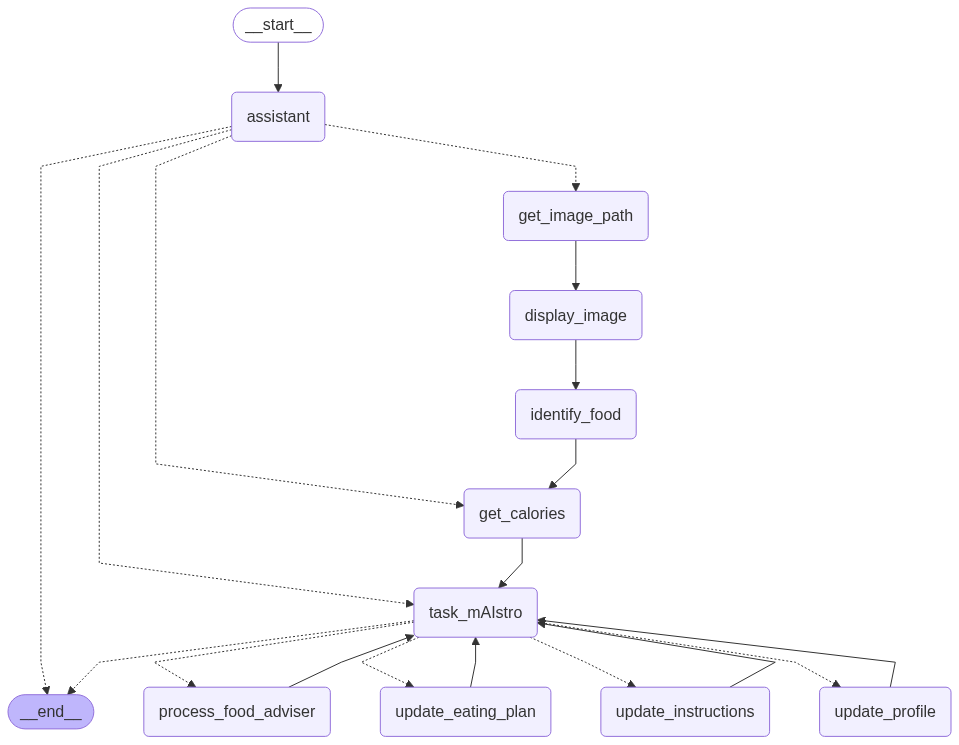

In [65]:
# Unified graph: supports text or image calorie estimation, then memory updates
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables import RunnableConfig
from langgraph.graph import MessagesState
from langchain_core.messages import merge_message_runs,HumanMessage, SystemMessage, ToolMessage
from langgraph.prebuilt import ToolNode
from trustcall import create_extractor
from typing import TypedDict, Literal, Union
from graph_nodes import State, assistant, upload_image, display_image, identify_food, get_calories, get_image_path_node
from graph_nodes import tools , tools_condition
from rag import get_rag


# from tools import tools, food_adviser_tool
from langchain_openai import ChatOpenAI
from datetime import datetime
import uuid

llm = ChatOpenAI(model="gpt-4o")
# llm = llm.bind_tools(tools, parallel_tool_calls=False)
rag_chain = get_rag(llm)

# Update memory tool
class UpdateMemory(TypedDict):
    """ Decision on what memory type to update """
    update_type: Literal['user', 'eating_plan', 'instructions']

from pydantic import BaseModel, Field

class Memory(BaseModel):
    content: str = Field(description="The main content of the memory. For example: User expressed interest in learning about French.")

class MemoryCollection(BaseModel):
    memories: list[Memory] = Field(description="A list of memories about the user.")

# Inspect the tool calls made by Trustcall
class Spy:
    def __init__(self):
        self.called_tools = []

    def __call__(self, run):
        # Collect information about the tool calls made by the extractor.
        q = [run]
        while q:
            r = q.pop()
            if r.child_runs:
                q.extend(r.child_runs)
            if r.run_type == "chat_model":
                self.called_tools.append(
                    r.outputs["generations"][0][0]["message"]["kwargs"]["tool_calls"]
                )

# Initialize the spy
spy = Spy()

# Initialize the model
model = ChatOpenAI(model="gpt-4o", temperature=0)

# Create the extractor
trustcall_extractor = create_extractor(
    model,
    tools=[Memory],
    tool_choice="Memory",
    enable_inserts=True,
)

# Add the spy as a listener
trustcall_extractor_see_all_tool_calls = trustcall_extractor.with_listeners(on_end=spy)

def extract_tool_info(tool_calls, schema_name="Memory"):
    """Extract information from tool calls for both patches and new memories.

    Args:
        tool_calls: List of tool calls from the model
        schema_name: Name of the schema tool (e.g., "Memory", "ToDo", "Profile")
    """

    # Initialize list of changes
    changes = []

    for call_group in tool_calls:
        for call in call_group:
            if call['name'] == 'PatchDoc':
                changes.append({
                    'type': 'update',
                    'doc_id': call['args']['json_doc_id'],
                    'planned_edits': call['args']['planned_edits'],
                    'value': call['args']['patches'][0]['value']
                })
            elif call['name'] == schema_name:
                changes.append({
                    'type': 'new',
                    'value': call['args']
                })

    # Format results as a single string
    result_parts = []
    for change in changes:
        if change['type'] == 'update':
            result_parts.append(
                f"Document {change['doc_id']} updated:\n"
                f"Plan: {change['planned_edits']}\n"
                f"Added content: {change['value']}"
            )
        else:
            result_parts.append(
                f"New {schema_name} created:\n"
                f"Content: {change['value']}"
            )

    return "\n\n".join(result_parts)

# Inspect spy.called_tools to see exactly what happened during the extraction
schema_name = "Memory"
changes = extract_tool_info(spy.called_tools, schema_name)
print(changes)

import uuid
from IPython.display import Image, display

from datetime import datetime
from trustcall import create_extractor
# from typing import Optional
from typing import Optional, List, Dict, Any, Union, Literal # Import Dict, Any, Union, Literal

from pydantic import BaseModel, Field

from langchain_core.runnables import RunnableConfig, Runnable
from langchain_core.messages import merge_message_runs, HumanMessage, SystemMessage, AIMessage, ToolMessage

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, END, START
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore


# User profile schema
class Profile(BaseModel):
    """This is the profile of the user you are chatting with"""
    name: Optional[str] = Field(description="The user's name", default=None)
    age: Optional[int] = Field(description="The user's age", default=None)
    weight: Optional[float] = Field(description="The user's weight", default=None)
    height: Optional[float] = Field(description="The user's height", default=None)
    gender: Optional[str] = Field(description="The user's gender", default=None)
    exercise_level: Optional[str] = Field(description="The user's  (amount of time spends on sport weekly)", default=None)
    diet_type: Optional[str] = Field(description="The user's diexercise level type", default=None)
    allergies: Optional[List[str]] = Field(description="The user's allergies",default_factory=list)
    medications: Optional[List[str]] = Field(description="The user's medications", default_factory=list)
    habits: Optional[List[str]] = Field(description="The user's habits", default_factory=list)
    preferences: Optional[List[str]] = Field(description="The user's preferences", default_factory=list)
    location: Optional[str] = Field(description="The user's location", default=None)
    job: Optional[str] = Field(description="The user's job", default=None)
    diet_goals: list[str] = Field(
        description="The user's dietary goals for which they are seeking advice, such as losing or gaining weight, improving fitness, addressing dietary restrictions like gluten intolerance.",
        default_factory=list
    )
    interests: list[str] = Field(
        description="Interests that the user has",
        default_factory=list
    )

    def estimated_tdee(self) -> Optional[float]:
        if self.weight and self.height and self.age and self.gender:
            if self.gender.lower() == "male":
                bmr = 10 * self.weight + 6.25 * self.height - 5 * self.age + 5
            else:
                bmr = 10 * self.weight + 6.25 * self.height - 5 * self.age - 161

            activity_multiplier = {
                "low": 1.2,
                "medium": 1.55,
                "high": 1.9
            }.get((self.exercise_level or "medium").lower(), 1.55)

            return round(bmr * activity_multiplier, 2)
        return None

from pydantic import BaseModel
from typing import Dict, Any, Optional, Union
from langchain_core.runnables import RunnableConfig

# Define the input schema for the tool
class FoodAdviserInputSchema(BaseModel):
    input_data: str  # The dish description or ingredients
    user_profile: Optional[Dict[str, Any]] = None  # Optional user profile to override what’s in memory

# Define the tool wrapper
class ToolWrapper:
    def __init__(self, func, name: str, description: str, input_schema: BaseModel):
        self.func = func
        self.name = name
        self.description = description
        self.input_schema = input_schema

    def invoke(self, input: Union[BaseModel, Dict[str, Any]], config: Optional[RunnableConfig] = None):
        if isinstance(input, dict):
            validated_input = self.input_schema(**input)
        else:
            validated_input = input
        return self.func(**validated_input.model_dump(), config=config)

    def __call__(self, input, config: Optional[RunnableConfig] = None):
        return self.invoke(input, config)

    def to_openai_function(self) -> Dict:
        return {
            "type": "function",
            "function": {
                "name": self.name,
                "description": self.description,
                "parameters": self.input_schema.model_json_schema()
            }
        }

# Bind the function to the tool (you already have the logic in `process_food_adviser`)
def food_adviser_function(input_data: str, user_profile: Optional[Dict[str, Any]] = None, config: Optional[RunnableConfig] = None):
    # You can leave this empty because `process_food_adviser` does the work,
    # or just use this as a dummy to meet the interface.
    return f"Processed input: {input_data} with profile: {user_profile}"

# Instantiate the tool for registration
food_adviser_tool = ToolWrapper(
    func=food_adviser_function,
    name="FoodAdviser",
    description="Provides food recommendations and calorie estimates based on profile and dish input.",
    input_schema=FoodAdviserInputSchema
)


from pydantic import BaseModel, Field
from typing import List, Optional

class FoodAdviser(BaseModel):
    calorie_estimations: List[str] = Field(
        description="Assistant's calorie estimations for dishes the user is considering.",
        default_factory=list
    )
    food_recommendations: List[str] = Field(
          description="Advice or suggestions regarding food choices, based on the user's profile and current dish.",
          default_factory=list
    )
    foods_consumed: List[str] = Field(
        description="Dishes or food items the user reported actually eating.",
        default_factory=list
    )
    current_time: str = Field(
        description="Time of day when the meal was eaten (e.g., 'morning', 'lunch', 'evening').",
        default=""
    )
    timestamp: Optional[str] = Field(
        description="Optional full timestamp for logging the event.",
        default=None
    )



# # --- Smart routing using AI ---
# def route_input_ai(state: MessagesState) -> str:
#     last_msg = state["messages"][-1]
#     router_instruction = (
#         "You are a router for a food adviser assistant.\n"
#         "Given the user's message, decide how to handle it:\n"
#         "- If it's an image upload (e.g., 'here is a photo', or triggered a tool call), return 'get_image_path'.\n"
#         "- If it's a dish description or food question in text, return 'get_calories'.\n"
#         "Respond only with one of: get_image_path, get_calories, END."
#     )
#     route_result = llm.invoke([
#         HumanMessage(content=router_instruction),
#         last_msg
#     ])
#     return route_result.content.strip() if route_result.content.strip() in ["get_image_path", "get_calories"] else END

# TRUSTCALL_INSTRUCTION = """Reflect on the following interaction.\n\nUse the provided tools to retain any necessary memories about the user.\n\nUse parallel tool calling to handle updates and insertions simultaneously.\n\nSystem Time: {time}"""
TRUSTCALL_INSTRUCTION = """Reflect on the user’s input and determine the appropriate memory update or food advisory task.

Use these rules:
- If the user shares **personal info** (e.g. health, goals, lifestyle) → call UpdateMemory with update_type: 'user'
- If they **describe something they ate** → call UpdateMemory with update_type: 'eating_plan'
- If they give **rules or expectations** (e.g. \"track daily\", \"remind me\") → call UpdateMemory with update_type: 'instructions'
- If they **ask for calories or food advice** (e.g. describe a dish they might eat) → call the FoodAdviser tool

Only log food if it was actually consumed.
Estimate calories and give advice even if it’s only being considered.
Respond naturally after taking any action.
"""

CREATE_INSTRUCTIONS = """Reflect on the following interaction.\n\nBased on this interaction, update your instructions for how to update FoodAdviser list items.\n\nUse any feedback from the user to update how they like to have items added, etc.\n\nYour current instructions are:\n\n<current_instructions>\n{current_instructions}\n</current_instructions>"""

# --- Reasoning Node ---
from langgraph.graph import MessagesState
from langchain_core.runnables import RunnableConfig
# from langgraph.checkpoint.base import BaseStore  # or InMemoryStore if you only use that

def task_mAIstro(state: MessagesState, config: RunnableConfig, store: BaseStore):
# def task_mAIstro(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
    user_id = config["configurable"]["user_id"]
    # profile = store.get(("profile", user_id)) or {}
    profile_item = store.get(("profile", user_id), "user_profile")
    profile = profile_item.value if profile_item else {}
    eating_plan_items = store.search(("eating_plan", user_id))
    # instructions_item = store.get(("instructions", user_id)) or {}
    instructions_item = store.get(("instructions", user_id), "user_instructions")
    instructions = instructions_item.value.get("memory") if instructions_item else ""


    eating_plan = "\n".join(str(mem.value) for mem in eating_plan_items)
    instructions = instructions_item.get("memory") if isinstance(instructions_item, dict) else str(instructions_item)
    trustcall_instruction = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())

    system_prompt = f"""
{trustcall_instruction}

<user_profile>
{profile}
</user_profile>

<eating_plan>
{eating_plan}
</eating_plan>

<instructions>
{instructions}
</instructions>

Instructions:
- Reflect on user goals, questions, or food reports.
- If they provide profile info → tool call: UpdateMemory type 'user'
- If they describe what they ate or got calorie estimates → UpdateMemory type 'eating_plan'
- If they define behavior ("track meals daily", "remind me later") → UpdateMemory type 'instructions'
- If they ask for food advice → call FoodAdviser tool
- Respond naturally, tell user if a meal was logged.
"""

    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    tools = [UpdateMemory, food_adviser_tool.to_openai_function()]
    result = llm.bind_tools(tools, parallel_tool_calls=False).invoke(messages)
    return {"messages": [result]}

# # --- Update Nodes ---
# def update_profile(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
#     user_id = config["configurable"]["user_id"]
#     namespace = ("profile", user_id)
#     existing_items = store.search(namespace)
#     tool_name = "Profile"
#     existing_memories = [
#         (item.key, tool_name, item.value) for item in existing_items
#     ] if existing_items else None

#     trust_msg = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
#     filtered_messages = [msg for msg in state["messages"] if not getattr(msg, "tool_calls", None)]
#     updated_messages = list(merge_message_runs(messages=[SystemMessage(content=trust_msg)] + filtered_messages[:-1]))

#     extractor = create_extractor(llm, tools=[Profile], tool_choice="Profile", enable_inserts=True)
#     result = extractor.invoke({"messages": updated_messages, "existing": existing_memories})

#     for r, rmeta in zip(result["responses"], result["response_metadata"]):
#         store.put(namespace, rmeta.get("json_doc_id", str(uuid.uuid4())), r.model_dump(mode="json"))

#     # call_id = state["messages"][-1].tool_calls[0]["id"]
#     # # return {"messages": [ToolMessage(content="User profile updated", tool_call_id=call_id)]}
#     # return {"messages": [ToolMessage(content="User profile updated", tool_call_id=tool_call_id_to_respond_to)]}
#     tool_calls = state['messages'][-1].tool_calls
# #     call_id = next(
# #     (tc['id'] for tc in tool_calls if tc['name'] == 'UpdateMemory' and tc['args'].get('update_type') == 'user'),
# #     None
# # )
#     tool_call_id = next(
#     (tc["id"] for msg in reversed(state["messages"])
#      if hasattr(msg, "tool_calls")
#      for tc in msg.tool_calls
#      if tc["name"] == "UpdateMemory" and tc["args"].get("update_type") == "user"),
#     None
# )

#     # if call_id:
#     #     return {"messages": [ToolMessage(content="User profile updated", tool_call_id=call_id)]}
#     # else:
#     #     return {"messages": [AIMessage(content="⚠️ No tool_call_id found for user profile update.")]}

#     if tool_call_id:
#         return {"messages": [ToolMessage(content="User profile updated", tool_call_id=tool_call_id)]}
#     else:
#         return {"messages": [AIMessage(content="⚠️ No tool_call_id found for user profile update.")]}


# --- Update Nodes ---
def update_profile(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("profile", user_id)
    existing_items = store.search(namespace)
    tool_name = "Profile"
    existing_memories = [
        (item.key, tool_name, item.value) for item in existing_items
    ] if existing_items else None

    # Find the tool_call_id from the assistant message that triggered this node
    tool_call_id = None
    # Iterate backwards through messages to find the assistant message that likely triggered this node
    for msg in reversed(state["messages"]):
        if hasattr(msg, "tool_calls") and msg.tool_calls:
             # Check if any tool call in this message is for UpdateMemory type 'user'
            for tc in msg.tool_calls:
                 # We assume the first tool call of the correct type is the one we're responding to
                if tc["name"] == "UpdateMemory" and tc["args"].get("update_type") == "user":
                    tool_call_id = tc["id"]
                    break
            if tool_call_id:
                break # Found the relevant tool call in this message

    trust_msg = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    filtered_messages = [msg for msg in state["messages"] if not getattr(msg, "tool_calls", None)]
    updated_messages = list(merge_message_runs(messages=[SystemMessage(content=trust_msg)] + filtered_messages[:-1]))

    extractor = create_extractor(llm, tools=[Profile], tool_choice="Profile", enable_inserts=True)
    # Pass the message history *without* the assistant's tool call if extractor is only meant to see user input
    # Or, if extractor can handle it, pass the full history
    # Let's try filtering out the assistant's tool call message to simplify the extractor's view
    messages_for_extractor = [msg for msg in state["messages"] if not (hasattr(msg, "tool_calls") and msg.tool_calls)]
    result = extractor.invoke({"messages": [SystemMessage(content=trust_msg)] + messages_for_extractor, "existing": existing_memories})


    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace, rmeta.get("json_doc_id", str(uuid.uuid4())), r.model_dump(mode="json"))

    if tool_call_id:
        print(f"✅ update_profile responding with tool_call_id: {tool_call_id}")
        return {"messages": [ToolMessage(content="User profile updated", tool_call_id=tool_call_id)]}
    else:
        print("⚠️ No matching tool_call_id found for user profile update.")
        # Return an AIMessage if no tool_call_id is found to avoid errors
        return {"messages": [AIMessage(content="Acknowledged: User profile info provided.")]}




# # --- Update Eating Plan ---
# def update_eating_plan(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
#     user_id = config["configurable"]["user_id"]
#     namespace = ("eating_plan", user_id)
#     existing_items = store.search(namespace)
#     tool_name = "FoodAdviser"
#     existing_memories = [
#         (item.key, tool_name, item.value) for item in existing_items
#     ] if existing_items else None

#     trust_msg = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
#     filtered_messages = [msg for msg in state["messages"] if not getattr(msg, "tool_calls", None)]
#     updated_messages = list(merge_message_runs(messages=[SystemMessage(content=trust_msg)] + filtered_messages[:-1]))

#     spy = Spy()
#     extractor = create_extractor(llm, tools=[FoodAdviser], tool_choice="any", enable_inserts=True).with_listeners(on_end=spy)
#     result = extractor.invoke({"messages": updated_messages, "existing": existing_memories})

#     for r, rmeta in zip(result["responses"], result["response_metadata"]):
#         store.put(namespace, rmeta.get("json_doc_id", str(uuid.uuid4())), r.model_dump(mode="json"))

#     # tool_call_id = state["messages"][-1].tool_calls[0]["id"]
#     # Find the last assistant message with tool_calls
#     tool_call_id = next(
#     (tc["id"] for msg in reversed(state["messages"])
#      if hasattr(msg, "tool_calls")
#      for tc in msg.tool_calls
#      if tc["name"] == "UpdateMemory" and tc["args"].get("update_type") == "eating_plan"),
#     None
# )

#     update_msg = extract_tool_info(spy.called_tools, tool_name)

#     if tool_call_id:
#       return {"messages": [ToolMessage(content=update_msg, tool_call_id=tool_call_id)]}
#     else:
#       return {"messages": [AIMessage(content="⚠️ No matching tool_call_id found for eating plan update.")]}

#     # return {"messages": [ToolMessage(content=update_msg, tool_call_id=tool_call_id)]}


# --- Update Eating Plan ---
def update_eating_plan(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("eating_plan", user_id)
    existing_items = store.search(namespace)
    tool_name = "FoodAdviser" # Note: update_eating_plan updates eating plan memories, often triggered by FoodAdviser or a report of consumption. The schema used by Trustcall here is FoodAdviser
    existing_memories = [
        (item.key, tool_name, item.value) for item in existing_items
    ] if existing_items else None

    # Find the tool_call_id from the assistant message that triggered this node
    tool_call_id = None
    for msg in reversed(state["messages"]):
        if hasattr(msg, "tool_calls") and msg.tool_calls:
             for tc in msg.tool_calls:
                if tc["name"] == "UpdateMemory" and tc["args"].get("update_type") == "eating_plan":
                    tool_call_id = tc["id"]
                    break
             print("🧪 Detected tool_call_id:", tool_call_id)
             if tool_call_id:
                 break

    trust_msg = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    # We need to pass messages relevant to eating plan updates. This might include the user's description or the FoodAdviser tool output.
    # For simplicity, let's try passing all non-tool messages again.
    filtered_messages = [msg for msg in state["messages"] if not getattr(msg, "tool_calls", None)]
    updated_messages = list(merge_message_runs(messages=[SystemMessage(content=trust_msg)] + filtered_messages[:-1]))

    spy = Spy() # Re-initialize spy for this specific node execution
    # Use FoodAdviser schema for extracting info about meals/advice
    extractor = create_extractor(llm, tools=[FoodAdviser], tool_choice="any", enable_inserts=True).with_listeners(on_end=spy)
     # Pass messages for extractor - might need to be careful what messages Trustcall sees here.
    # Let's try passing the latest few messages, including the user's input
    messages_for_extractor = [SystemMessage(content=trust_msg)] + state["messages"][-3:] # Adjust slice as needed
    result = extractor.invoke({"messages": messages_for_extractor, "existing": existing_memories})


    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        # Trustcall returns objects based on the schema (FoodAdviser), not necessarily Memory
        # Ensure we are saving the extracted content correctly.
        # Assuming r.model_dump(mode="json") gives us the dictionary representation of the FoodAdviser object
        store.put(namespace, rmeta.get("json_doc_id", str(uuid.uuid4())), r.model_dump(mode="json"))


    update_msg_content = extract_tool_info(spy.called_tools, tool_name) # Use FoodAdviser as schema name

    if tool_call_id:
        print(f"✅ update_eating_plan responding with tool_call_id: {tool_call_id}")
        return {"messages": [ToolMessage(content=update_msg_content, tool_call_id=tool_call_id)]}
    else:
        print("⚠️ No matching tool_call_id found for eating plan update.")
        return {"messages": [AIMessage(content="Acknowledged: Eating plan info updated.")]}




# def update_instructions(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
#     user_id = config["configurable"]["user_id"]
#     namespace = ("instructions", user_id)
#     key = "user_instructions"
#     existing = store.get(namespace, key)
#     current = existing.value.get("memory") if existing and isinstance(existing.value, dict) else ""

#     system_msg = CREATE_INSTRUCTIONS.format(current_instructions=current)
#     filtered_messages = [msg for msg in state["messages"] if not getattr(msg, "tool_calls", None)]
#     result = llm.invoke([SystemMessage(content=system_msg)] + filtered_messages[:-1] + [HumanMessage(content="Please update the instructions based on the conversation")])

#     store.put(namespace, key, {"memory": result.content})
#     # call_id = state["messages"][-1].tool_calls[0]["id"]
#     # Find the last assistant message with tool_calls
#     tool_call_id = next(
#     (tc["id"] for msg in reversed(state["messages"])
#      if hasattr(msg, "tool_calls")
#      for tc in msg.tool_calls
#      if tc["name"] == "UpdateMemory" and tc["args"].get("update_type") == 'instructions'),
#     None
# )

#     # return {"messages": [ToolMessage(content="Updated instructions for eating plan tracking.", tool_call_id=call_id)]}
#     if tool_call_id:
#       return {"messages": [ToolMessage(content="Updated instructions for eating plan tracking.", tool_call_id=tool_call_id)]}
#     else:
#       return {"messages": [AIMessage(content="⚠️ No matching tool_call_id found for updated instructions update.")]}


def update_instructions(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("instructions", user_id)
    key = "user_instructions"
    existing = store.get(namespace, key)
    current = existing.value.get("memory") if existing and isinstance(existing.value, dict) else ""

     # Find the tool_call_id from the assistant message that triggered this node
    tool_call_id = None
    for msg in reversed(state["messages"]):
        if hasattr(msg, "tool_calls") and msg.tool_calls:
             for tc in msg.tool_calls:
                if tc["name"] == "UpdateMemory" and tc["args"].get("update_type") == 'instructions':
                    tool_call_id = tc["id"]
                    break
        if tool_call_id:
          break

    system_msg = CREATE_INSTRUCTIONS.format(current_instructions=current)
    # Pass messages relevant to instructions update. This might be the user's request or feedback.
    # Let's pass the latest few messages.
    messages_for_llm = [SystemMessage(content=system_msg)] + state["messages"][-3:] # Adjust slice as needed
    # Ensure the last message for the LLM is not a tool call if it expects user input
    if hasattr(messages_for_llm[-1], "tool_calls") and messages_for_llm[-1].tool_calls:
         messages_for_llm = messages_for_llm[:-1] + [HumanMessage(content="Please update the instructions based on the conversation")] # Add a dummy HumanMessage if needed


    result = llm.invoke(messages_for_llm)

    store.put(namespace, key, {"memory": result.content})

    if tool_call_id:
        print(f"✅ update_instructions responding with tool_call_id: {tool_call_id}")
        return {"messages": [ToolMessage(content="Updated instructions for eating plan tracking.", tool_call_id=tool_call_id)]}
    else:
        print("⚠️ No matching tool_call_id found for updated instructions update.")
        return {"messages": [AIMessage(content="Acknowledged: Instructions updated.")]}

# # --- Tool Schema & Wrapper ---
# from pydantic import BaseModel
# from typing import Dict, Any, Optional, Union
# from langchain_core.runnables import RunnableConfig

# class FoodAdviserInputSchema(BaseModel):
#     input_data: str
#     user_profile: Optional[Dict[str, Any]] = None

# class ToolWrapper:
#     def __init__(self, func, name: str, description: str, input_schema: BaseModel):
#         self.func = func
#         self.name = name
#         self.description = description
#         self.input_schema = input_schema

#     def invoke(self, input: Union[BaseModel, Dict[str, Any]], config: Optional[RunnableConfig] = None):
#         if isinstance(input, dict):
#             validated_input = self.input_schema(**input)
#         else:
#             validated_input = input
#         return self.func(**validated_input.model_dump(), config=config)

#     def __call__(self, input, config: Optional[RunnableConfig] = None):
#         return self.invoke(input, config)

#     def to_openai_function(self) -> Dict:
#         return {
#             "type": "function",
#             "function": {
#                 "name": self.name,
#                 "description": self.description,
#                 "parameters": self.input_schema.model_json_schema()
#             }
#         }

# def food_adviser_function(input_data: str, user_profile: Optional[Dict[str, Any]] = None, config: Optional[RunnableConfig] = None):
#     return f"Processed input: {input_data} with profile: {user_profile}"

# food_adviser_tool = ToolWrapper(
#     func=food_adviser_function,
#     name="FoodAdviser",
#     description="Provides food recommendations and calorie estimates based on profile and dish input.",
#     input_schema=FoodAdviserInputSchema
# )

# # --- Process Food Adviser ---
# def process_food_adviser(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
#     message = state['messages'][-1]
#     tool_calls = message.tool_calls

#     if not tool_calls or tool_calls[0]['name'] != food_adviser_tool.name:
#         err_msg = "Expected FoodAdviser tool call but didn’t find one."
#         return {"messages": [ToolMessage(content=err_msg, tool_call_id=tool_calls[0]['id'] if tool_calls else None)]}

#     tool_call = tool_calls[0]
#     tool_call_id = tool_call['id']
#     tool_args = tool_call['args']

#     try:
#         input_data = tool_args.get("input_data", "")
#         user_profile = tool_args.get("user_profile", {})
#         user_id = config["configurable"]["user_id"]

#         # Retrieve past eating plan memories to provide context
#         history_items = store.search(("eating_plan", user_id))
#         history = "".join(str(item.value) for item in history_items[-5:]) if history_items else ""

#         # Construct a prompt to get a personalized recommendation
#         prompt = f"""You are a health-focused nutrition adviser. Based on the dish described below and the user's profile and recent eating history, give a clear and personalized recommendation. Be concise, and avoid generic statements.

# Dish description:
# {input_data}

# User profile:
# {user_profile}

# Recent eating history:
# {history}

# What is your personalized dietary recommendation?
# """

#         result = llm.invoke([HumanMessage(content=prompt)]).content

#         # Save the recommendation
#         timestamp = datetime.now().isoformat()
#         memory_entry = {
#             "content": result,
#             "timestamp": timestamp,
#             "type": "food_advice",
#             "dish": input_data,
#             "profile": user_profile
#         }
#         store.put(("eating_plan", user_id), str(uuid.uuid4()), memory_entry)

#         return {"messages": [ToolMessage(content=result, tool_call_id=tool_call_id)]}

#     except Exception as e:
#         return {"messages": [ToolMessage(content=f"Error: {str(e)}", tool_call_id=tool_call_id)]}

#     except Exception as e:
#         return {"messages": [ToolMessage(content=f"Error: {str(e)}", tool_call_id=tool_call_id)]}

# # --- Routing Logic ---
# from typing import Union, Literal

# ReturnType = Union[type(END), Literal[
#     "update_eating_plan", "update_instructions", "update_profile", "process_food_adviser"
# ]]

ROUTE_MAP = {
    ("UpdateMemory", "user"): "update_profile",
    ("UpdateMemory", "eating_plan"): "update_eating_plan",
    ("UpdateMemory", "instructions"): "update_instructions",
    (food_adviser_tool.name, None): "process_food_adviser",
}

# def route_message(state: MessagesState, config: RunnableConfig, store: BaseStore) -> ReturnType:
#     message = state['messages'][-1]

#     if not message.tool_calls:
#         return END

#     tool_call = message.tool_calls[0]
#     tool_name = tool_call.get("name")
#     update_type = tool_call.get("args", {}).get("update_type")

#     return ROUTE_MAP.get((tool_name, update_type), END)

# --- Tool Schema & Wrapper ---
from pydantic import BaseModel
from typing import Dict, Any, Optional, Union
from langchain_core.runnables import RunnableConfig

class FoodAdviserInputSchema(BaseModel):
    input_data: str
    user_profile: Optional[Dict[str, Any]] = None

class ToolWrapper:
    def __init__(self, func, name: str, description: str, input_schema: BaseModel):
        self.func = func
        self.name = name
        self.description = description
        self.input_schema = input_schema

    def invoke(self, input: Union[BaseModel, Dict[str, Any]], config: Optional[RunnableConfig] = None):
        if isinstance(input, dict):
            validated_input = self.input_schema(**input)
        else:
            validated_input = input
        return self.func(**validated_input.model_dump(), config=config)

    def __call__(self, input, config: Optional[RunnableConfig] = None):
        return self.invoke(input, config)

    def to_openai_function(self) -> Dict:
        return {
            "type": "function",
            "function": {
                "name": self.name,
                "description": self.description,
                "parameters": self.input_schema.model_json_schema()
            }
        }

def food_adviser_function(input_data: str, user_profile: Optional[Dict[str, Any]] = None, config: Optional[RunnableConfig] = None):
    return f"Processed input: {input_data} with profile: {user_profile}"

food_adviser_tool = ToolWrapper(
    func=food_adviser_function,
    name="FoodAdviser",
    description="Provides food recommendations and calorie estimates based on profile and dish input.",
    input_schema=FoodAdviserInputSchema
)

# # --- Process Food Adviser ---
# def process_food_adviser(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
#     message = state['messages'][-1]
#     tool_calls = message.tool_calls

#     if not tool_calls:
#         return {"messages": [AIMessage(content="❌ No tool call found for FoodAdviser.")]}

#     if tool_calls[0]['name'] != food_adviser_tool.name:
#         return {"messages": [ToolMessage(content="Unexpected tool call. Expected FoodAdviser.", tool_call_id=tool_calls[0]['id'])]}

#     tool_call = tool_calls[0]
#     tool_call_id = tool_call['id']
#     print("✅ tool_call_id from model:", tool_call_id)
#     print("🟨 Available tool_calls:", tool_calls)
#     tool_args = tool_call['args']

#     try:
#         input_data = tool_args.get("input_data", "")
#         user_profile = tool_args.get("user_profile", {})
#         user_id = config["configurable"]["user_id"]

#         history_items = store.search(("eating_plan", user_id))
#         history = "\n".join(str(item.value) for item in history_items[-5:]) if history_items else ""

#         # Ask calorie estimation first
#         calorie_prompt = f"""
# Estimate the total number of calories in the following dish:

# Dish:
# {input_data}
# """
#         calorie_result = rag_chain.invoke({"input": calorie_prompt})['answer']

#         # Add calorie estimation message
#         calorie_msg = ToolMessage(content=f"Estimated calories for '{input_data}': {calorie_result}", tool_call_id=tool_call_id + "_calories")

#         # Then, ask for food advice with the calorie info in context
#         prompt = f"""
# You are a health-focused nutrition adviser. Based on the dish described below, the user's profile, recent eating history, and estimated calories, give a clear and personalized recommendation. Be concise, and avoid generic statements.

# Dish description:
# {input_data}

# Estimated calories:
# {calorie_result}

# User profile:
# {user_profile}

# Recent eating history:
# {history}

# What is your personalized dietary recommendation?
# """

#         result = llm.invoke([HumanMessage(content=prompt)]).content

#         timestamp = datetime.now().isoformat()
#         memory_entry = {
#             "content": result,
#             "timestamp": timestamp,
#             "type": "food_advice",
#             "dish": input_data,
#             "profile": user_profile,
#             "estimated_calories": calorie_result
#         }
#         store.put(("eating_plan", user_id), str(uuid.uuid4()), memory_entry)

#         # return {"messages": [
#         #     calorie_msg,
#         #     ToolMessage(content=result, tool_call_id=tool_call_id)
#         # ]}
#         print(f"✅ Returning ToolMessage with tool_call_id={tool_call_id}")


#         # combined_content = f"{calorie_msg.content}\n\nAdvice:\n{result}"
#         combined_content = f"Estimated calories for '{input_data}': {calorie_result}\n\nAdvice:\n{result}"

#         return {"messages": [ToolMessage(content=combined_content, tool_call_id=tool_call_id)]}

#     except Exception as e:
#         return {"messages": [ToolMessage(content=f"Error: {str(e)}", tool_call_id=tool_call_id)]}

# # --- Process Food Adviser ---
def process_food_adviser(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
    message = state['messages'][-1]
    tool_calls = message.tool_calls

    if not tool_calls:
        print("❌ process_food_adviser: No tool call found.")
        return {"messages": [AIMessage(content="❌ No tool call found for FoodAdviser.")]}

    # Find the specific FoodAdviser tool call we need to respond to
    tool_call = None
    tool_call_id = None
    for tc in tool_calls:
        if tc.get('name') == food_adviser_tool.name:
            tool_call = tc
            tool_call_id = tc['id']
            break

    if not tool_call:
         print("❌ process_food_adviser: Expected FoodAdviser tool call but didn’t find one.")
         return {"messages": [AIMessage(content="Unexpected tool call. Expected FoodAdviser.")]} # No tool_call_id to respond to here

    print("✅ process_food_adviser running.")
    print(f"✅ Tool_call_id to respond to: {tool_call_id}")
    print("🟨 Available tool_calls:", tool_calls)
    tool_args = tool_call['args']

    try:
        input_data = tool_args.get("input_data", "")
        user_profile = tool_args.get("user_profile", {})
        user_id = config["configurable"]["user_id"]

        history_items = store.search(("eating_plan", user_id))
        history = "\n".join(str(item.value) for item in history_items[-5:]) if history_items else ""

        # Ask calorie estimation first
        calorie_prompt = f"""
Estimate the total number of calories in the following dish:

Dish:
{input_data}
"""
        print(f"Invoking RAG chain for calorie estimation with input: {calorie_prompt}")
        # Use a slightly different tool_call_id for the internal calorie estimation message if needed,
        # but the final response to the assistant should use the original tool_call_id.
        calorie_result = rag_chain.invoke({"input": calorie_prompt})['answer']
        print(f"RAG chain returned: {calorie_result}")

        # Then, ask for food advice with the calorie info in context
        prompt = f"""
You are a health-focused nutrition adviser. Based on the dish described below, the user's profile, recent eating history, and estimated calories, give a clear and personalized recommendation. Be concise, and avoid generic statements.

Dish description:
{input_data}

Estimated calories:
{calorie_result}

User profile:
{user_profile}

Recent eating history:
{history}

What is your personalized dietary recommendation?
"""
        print("Invoking LLM for food advice.")
        result = llm.invoke([HumanMessage(content=prompt)]).content
        print(f"LLM returned advice: {result}")


        timestamp = datetime.now().isoformat()
        memory_entry = {
            "content": result,
            "timestamp": timestamp,
            "type": "food_advice",
            "dish": input_data,
            "profile": user_profile,
            "estimated_calories": calorie_result
        }
        # Save the advice and estimated calories to eating plan memory
        store.put(("eating_plan", user_id), str(uuid.uuid4()), memory_entry)
        print(f"Saved memory entry: {memory_entry}")


        # Combined content for the final ToolMessage
        combined_content = f"Estimated calories for '{input_data}': {calorie_result}\n\nAdvice:\n{result}"

        print(f"✅ Returning ToolMessage with tool_call_id={tool_call_id}")
        # Corrected indentation for the return statement
        return {"messages": [ToolMessage(content=combined_content, tool_call_id=tool_call_id)]}

    except Exception as e:
        print(f"❌ Error in process_food_adviser: {str(e)}")
        # Ensure we return a ToolMessage with the correct ID in case of error
        if tool_call_id:
             # Corrected indentation for the return statement inside the if
             return {"messages": [ToolMessage(content=f"Error processing food request: {str(e)}", tool_call_id=tool_call_id)]}
        else:
             return {"messages": [AIMessage(content=f"Error processing food request: {str(e)}")]}

# # --- Calorie Estimation from Image or Text ---
# def get_calories(state: MessagesState):
#     food_items = state.get("img_interpertation") or state.get("text_description")
#     if not food_items:
#         return {"messages": [AIMessage(content="I couldn't find a dish description to analyze. Please describe or upload an image.")]}

#     response = rag_chain.invoke({"input": f"How much food energy is in {food_items}?"})
#     print(response['answer'])
#     return {"messages": response['answer']}

# --- Routing Logic ---
from typing import Union, Literal

ReturnType = Union[type(END), Literal[
    "update_eating_plan", "update_instructions", "update_profile", "process_food_adviser", "task_mAIstro"
]]


# def route_input_ai(state: MessagesState, config: RunnableConfig, store: InMemoryStore) -> ReturnType:
#     last_message = state["messages"][-1]
#     message_text = last_message.content if hasattr(last_message, "content") else ""

#     print("✅ route_input_ai is running.")
#     print("Profile memory:", store.search(("profile", config["configurable"]["user_id"])))


#     routing_prompt = f"""
# You are a router. Based on the user's message, decide what function the assistant should perform:

# Available options:
# 1. get_image_path - if the user wants to upload an image of food
# 2. get_calories - if the user describes a food dish or asks for calories
# 3. task_mAIstro - if the user is giving general info, goals, or preferences (e.g. about pregnancy, goals, etc.)

# Only respond with one of: get_image_path, get_calories, task_mAIstro.

# User message:
# {message_text}
# """

#     response = llm.invoke([HumanMessage(content=routing_prompt)]).content.strip().lower()

#     if response in {"get_image_path", "get_calories", "task_mAIstro"}:
#         return response
#     else:
#         return "task_mAIstro"

# ROUTE_MAP = {
#     ("UpdateMemory", "user"): "update_profile",
#     ("UpdateMemory", "eating_plan"): "update_eating_plan",
#     ("UpdateMemory", "instructions"): "update_instructions",
#     (food_adviser_tool.name, None): "process_food_adviser",
# }

def route_input_ai(state: MessagesState, config: RunnableConfig, store: InMemoryStore) -> ReturnType:
    last_message = state["messages"][-1]

    # ✅ Check for tool call triggered by the assistant
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        tool_name = last_message.tool_calls[0]["name"]
        print(f"🔧 Tool call detected: {tool_name}")
        return tool_name

    # ✅ Fallback to natural language routing
    message_text = last_message.content if hasattr(last_message, "content") else ""
    print("✅ route_input_ai is running.")
    print("Profile memory:", store.search(("profile", config["configurable"]["user_id"])))

    routing_prompt = f"""
You are a router. Based on the user's message, decide what function the assistant should perform:

Available options:
1. get_image_path - if the user wants to upload an image of food
2. get_calories - if the user describes a food dish or asks for calories
3. task_mAIstro - if the user is giving general info, goals, or preferences (e.g. about pregnancy, goals, etc.)

Only respond with one of: get_image_path, get_calories, task_mAIstro.

User message:
{message_text}
"""

    response = llm.invoke([HumanMessage(content=routing_prompt)]).content.strip().lower()

    if response in {"get_image_path", "get_calories", "task_mAIstro"}:
        return response
    else:
        return "task_mAIstro"



# def route_message(state: MessagesState, config: RunnableConfig, store: BaseStore) -> ReturnType:
#     message = state['messages'][-1]

#     if not message.tool_calls:
#         return END

#     tool_call = message.tool_calls[0]
#     tool_name = tool_call.get("name")
#     update_type = tool_call.get("args", {}).get("update_type")

#     return ROUTE_MAP.get((tool_name, update_type), END)

def route_message(state: MessagesState, config: RunnableConfig, store: BaseStore) -> ReturnType:
    message = state['messages'][-1]

    if not message.tool_calls:
        return END

    tool_call = message.tool_calls[0]
    tool_name = tool_call.get("name")
    update_type = tool_call.get("args", {}).get("update_type")

    # Debugging and confirmation
    tool_call_id_to_respond_to = next(
        (tc['id'] for tc in message.tool_calls if tc['name'] == tool_name),
        None
    )
    print(f"Routing tool call: {tool_name}, update_type: {update_type}, id: {tool_call_id_to_respond_to}")

    return ROUTE_MAP.get((tool_name, update_type), END)


# --- Graph Definition ---
workflow = StateGraph(MessagesState)
workflow.add_node("assistant", assistant)
workflow.add_node("get_image_path", ToolNode([get_image_path]))
# workflow.add_node("get_image_path", get_  image_path)
# workflow.add_node("get_image_path", get_image_path_node)
workflow.add_node("display_image", display_image)
workflow.add_node("identify_food", identify_food)
workflow.add_node("get_calories", get_calories)
workflow.add_node("task_mAIstro", task_mAIstro)
# workflow.add_node("update_profile", update_profile)
# workflow.add_node("update_eating_plan", update_eating_plan)
# workflow.add_node("update_instructions", update_instructions)
# workflow.add_node("process_food_adviser", process_food_adviser)

workflow.add_node("update_profile", lambda state, config: update_profile(state, config, store))
workflow.add_node("update_eating_plan", lambda state, config: update_eating_plan(state, config, store))
workflow.add_node("update_instructions", lambda state, config: update_instructions(state, config, store))
workflow.add_node("process_food_adviser", lambda state, config: process_food_adviser(state, config, store))




workflow.set_entry_point("assistant")
# workflow.add_conditional_edges("assistant", route_input_ai, {
#     "get_image_path": "get_image_path",
#     "get_calories": "get_calories",
#     "task_mAIstro": "task_mAIstro",
#     END: END
# })


workflow.add_conditional_edges(
    "assistant",
    lambda state, config: route_input_ai(state, config, store),
    {
        "get_image_path": "get_image_path",
        "get_calories": "get_calories",
        "task_mAIstro": "task_mAIstro",
        END: END,
    }
)


workflow.add_edge("get_image_path", "display_image")
workflow.add_edge("display_image", "identify_food")
workflow.add_edge("identify_food", "get_calories")
workflow.add_edge("get_calories", "task_mAIstro")
workflow.add_conditional_edges("task_mAIstro", route_message, {
    "update_profile": "update_profile",
    "update_eating_plan": "update_eating_plan",
    "update_instructions": "update_instructions",
    "process_food_adviser": "process_food_adviser",
    END: END
})

workflow.add_edge("update_profile", "task_mAIstro")
workflow.add_edge("update_eating_plan", "task_mAIstro")
workflow.add_edge("update_instructions", "task_mAIstro")
workflow.add_edge("process_food_adviser", "task_mAIstro")

checkpointer = MemorySaver()
store = InMemoryStore()
graph = workflow.compile(checkpointer=checkpointer, store=store)


# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))


In [66]:
# Tools must be provided in OpenAI function format, not as ToolWrapper objects
# tools = [UpdateMemory, openai_tool]

# Define configuration
config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}
input_messages = [HumanMessage(content="I'm pregnant and want to control my weight. What can I eat?")]

# Execute the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

# for chunk in graph.stream({"messages": input_messages, "functions": tools}, config, stream_mode="values"):
#     chunk["messages"][-1].pretty_print()


================================ Human Message =================================

I'm pregnant and want to control my weight. What can I eat?
✅ route_input_ai is running.
Profile memory: []
================================== Ai Message ==================================

Maintaining a healthy diet during pregnancy is essential both for your health and the health of your baby. Here are some guidelines and foods you can include in your diet:

### 1. **Balanced Diet:**
- **Fruits and Vegetables:** Aim for a variety of colors to ensure a range of nutrients. These are high in vitamins, minerals, and fiber.
- **Whole Grains:** Such as whole wheat bread, brown rice, and oatmeal. These provide essential carbohydrates, fiber, and energy.
- **Proteins:** Lean meats, eggs, dairy products, legumes, nuts, and seeds. These are crucial for the growth of your baby.
- **Dairy:** Aim for low-fat or fat-free options that provide calcium, protein, and Vitamin D.

### 2. **Foods to Focus On:**
- **Folate-R

In [67]:
# Tools must be provided in OpenAI function format, not as ToolWrapper objects
# tools = [UpdateMemory, openai_tool]

# Define configuration
config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}
input_messages = [HumanMessage(content="I'm at my favorit resturant. I'm thinking of ordering a pasta with mushrooms and heavy cream. Is it advisable?")]

# # Execute the graph
# for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
#     chunk["messages"][-1].pretty_print()

# for chunk in graph.stream({"messages": input_messages, "functions": tools}, config, stream_mode="values"):
#     chunk["messages"][-1].pretty_print()


def continue_after_tool_call(messages, response_message):
    """
    Checks if the response_message contains 'tool_calls'.
    If yes, creates corresponding responses and appends them to the message list.
    """
    # Check if 'tool_calls' are present
    if 'tool_calls' in response_message:
        for tool_call in response_message['tool_calls']:
            # Generate a response message for this tool call
            tool_response_msg = {
                "role": "function",  # or "assistant" depending on your context
                "content": f"Responding to tool call {tool_call['name']}",
                "tool_call_id": tool_call['id']
            }
            # Append the response message
            messages.append(tool_response_msg)
        # After appending responses, you need to re-invoke or continue the conversation
        return messages
    # If no tool_call, just return messages as-is
    return messages

# Usage example with graph.stream()
messages = input_messages.copy()
for chunk in graph.stream({"messages": messages}, config, stream_mode="values"):
    last_msg = chunk["messages"][-1]
    last_msg.pretty_print()

    # Detect if the last message has tool_calls
    if hasattr(last_msg, 'get') and 'tool_calls' in last_msg:
        # Convert message to dict for easier handling
        msg_dict = last_msg.model_dump()
        messages = continue_after_tool_call(messages, msg_dict)
        # Continue the conversation after adding responses
        # Re-invoke or continue as needed
        # For example, re-invoke the graph with updated messages
        result = graph.invoke({"messages": messages}, config=config)
        # Update messages for next iteration
        messages = result["messages"]



================================ Human Message =================================

I'm at my favorit resturant. I'm thinking of ordering a pasta with mushrooms and heavy cream. Is it advisable?
✅ route_input_ai is running.
Profile memory: [Item(namespace=['profile', 'Bar'], key='bb7a6436-08e8-4088-a4ba-c5096dd16c76', value={'name': None, 'age': None, 'weight': None, 'height': None, 'gender': None, 'exercise_level': None, 'diet_type': None, 'allergies': [], 'medications': [], 'habits': [], 'preferences': [], 'location': None, 'job': None, 'diet_goals': ['control weight', 'pregnant'], 'interests': []}, created_at='2025-05-25T19:50:35.002850+00:00', updated_at='2025-05-25T19:50:35.002853+00:00', score=None)]
================================== Ai Message ==================================

Pasta with mushrooms and heavy cream is a delicious choice, but it might not be the best option if you're trying to control your weight during pregnancy. Here’s why and some alternatives:

### Nutritional

Testing graph with image input:
Node: HumanMessage
Content: Here's a photo of my meal.
--------------------------------------------------
🔧 Tool call detected: get_image_path
Node: AIMessage
Content: Please upload your image so I can analyze it.
Tool calls: [{'name': 'get_image_path', 'args': {}, 'id': 'call_WG66GGyOXwYyXyn7fqqq4zWq', 'type': 'tool_call'}]
--------------------------------------------------
✅ Tool ran — uploading file


Saving salmon.jpg to salmon.jpg
✅ Uploaded file: salmon.jpg
Node: ToolMessage
Content: {"img_path": "salmon.jpg"}
--------------------------------------------------


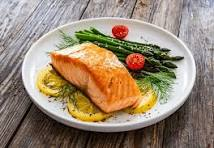

/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjL/wAARCACUANYDASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJipKTlJWWl5iZmqKjpKWmp6ipqrKztLW2t7i5usLDxMXGx8jJytLT1NXW19jZ2uHi4+Tl5ufo6erx8vP09fb3+Pn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3+Pn6/9oADAMBAAIRAxEAPwD0owwxRKPvH09SfWs2aQ2BcxTma4cjC7chR/iatSXHlTPcTOAictnt7f8A1qZAEkvTPNbt97Mb9jnuK0uKxbs5prLTzPdA+c56HnBPRR/jUEFzNcSM8wRTuwlTXlxFHKok/wCWYJ45wxFVRexLA884XyYxnPqewpMaH3U6oFRQ

In [64]:
# Test the graph
if __name__ == "__main__":
    from langchain_core.messages import HumanMessage

    input_messages = [HumanMessage(content="Here's a photo of my meal.")]
    config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}

    print("Testing graph with image input:")
    try:
        for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
            last_msg = chunk["messages"][-1]
            print(f"Node: {last_msg.__class__.__name__}")
            print(f"Content: {last_msg.content}")
            if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                print(f"Tool calls: {last_msg.tool_calls}")
            print("-" * 50)
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

Testing graph with image input:
Node: HumanMessage
Content: My name is Bar and I'm turning 38 next month. This is my third pregnency. I'm quite worried about my body - I want to remain fit. I'm at a resturant for launch time. Here's a photo of what I think to eat:.
--------------------------------------------------
🔧 Tool call detected: get_image_path
Node: AIMessage
Content: Please upload your image so I can analyze it.
Tool calls: [{'name': 'get_image_path', 'args': {}, 'id': 'call_NfoEVwlLa6ZMOGxnSmAGU0Qz', 'type': 'tool_call'}]
--------------------------------------------------
✅ Tool ran — uploading file


Saving lunch_option.jpeg to lunch_option.jpeg
✅ Uploaded file: lunch_option.jpeg
Node: ToolMessage
Content: {"img_path": "lunch_option.jpeg"}
--------------------------------------------------


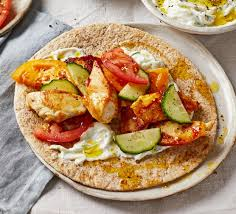

...
Node: AIMessage
Content: Image loaded: lunch_option.jpeg
--------------------------------------------------
================================== Ai Message ==================================

The dish in the image appears to be a chicken gyro wrap. Here is a possible list of the ingredients along with an estimated weight for each ingredient:

1. Whole wheat pita bread - 80 grams
2. Grilled chicken breast (sliced) - 100 grams
3. Tomato slices - 50 grams
4. Cucumber slices - 30 grams
5. Tzatziki sauce - 30 grams
6. Red onion (optional, not clearly visible but common in gyros) - 20 grams

Please note that these weights are estimations based on typical serving sizes for the components of a chicken gyro wrap. The actual weights could vary depending on specific recipes or serving preferences.
None
Node: AIMessage
Content: The dish in the image appears to be a chicken gyro wrap. Here is a possible list of the ingredients along with an estimated weight for each ingredient:

1. Whole wheat pi

In [69]:
# Test the graph
if __name__ == "__main__":
    from langchain_core.messages import HumanMessage

    input_messages = [HumanMessage(content="My name is Bar and I'm turning 38 next month. This is my third pregnency. I'm quite worried about my body - I want to remain fit. I'm at a resturant for lunch time. Here's a photo of what I think to eat:.")]
    config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}

    print("Testing graph with image input:")
    try:
        for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
            last_msg = chunk["messages"][-1]
            print(f"Node: {last_msg.__class__.__name__}")
            print(f"Content: {last_msg.content}")
            if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                print(f"Tool calls: {last_msg.tool_calls}")
            print("-" * 50)
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()
